In [1]:
PRED_CSV_DIR = r"G:\work\Secondary_Selection\All_possible_DA_ZINC"
PRED_BO_CSV_DIR = r"G:\work\Secondary_Selection\All_possible_DA_ZINC_BO"
PRED_CSV_ONE_DIR = r"G:\work\Secondary_Selection\All_possible_DA_One_ZINC"
PRED_BO_CSV_ONE_DIR = r"G:\work\Secondary_Selection\All_possible_DA_One_ZINC_BO"
SMILES_DIR= r"G:\work\Secondary_Selection\Diene_Ene_Smiles"
CSV_FILE_DIR= r"Data/DFT_Result"
QM_MAP = CSV_FILE_DIR + "/" + "all_property_detailSterimol_witharea.pkl" # Copy from smiles_csv

# 1 Import

In [2]:
%load_ext autoreload
%autoreload 2
%matplotlib inline
import warnings 
warnings.filterwarnings("ignore")

In [3]:
import os
import seaborn as sns

In [4]:
import glob, shutil
import pandas as pd
# import gendes
import pickle
import numpy as np
from matplotlib import pyplot as plt
from rdkit import Chem
# from hyperopt import hp
from tqdm import tqdm
from sklearn.base import clone
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from scipy.stats import pearsonr

from Code import cycle_process, model_train

In [5]:
# Tree
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor, AdaBoostRegressor, ExtraTreesRegressor
# from xgboost import XGBRegressor
from catboost import CatBoostRegressor
# Linear 
from sklearn.linear_model import Lasso, Ridge, BayesianRidge, SGDRegressor, LinearRegression
# SVM
from sklearn.svm import SVR
# Nearest Neighbour
from sklearn.neighbors import KNeighborsRegressor

In [6]:
def calc_distribution2(y, eachsize=0.01, title=None, xlab=None, ylab=None, y_max=None, y_min=None, color='blue', hight=None):
    if y_max == None:    y_max = np.max(y)
    if y_min == None:    y_min = np.min(y)
    X = np.arange(y_min, y_max + eachsize, eachsize)
    des = [0 for each in X]
    z = (y - y_min)/eachsize
    for each in z:
        try:
            assert int(each) < len(X)
            des[int(each)] += 1
        except:
            continue
    des = np.array(des)
    # des = des / len(y)
    
    fig = plt.figure(figsize=(4,3))
    ax = fig.add_subplot(111)
    ax.patch.set_alpha(0.0)

    # list_1 = [idx for idx, each in enumerate(X) if each < 15]
    # list_2 = [idx for idx, each in enumerate(X) if each >= 15 and each < 24]
    # list_3 = [idx for idx, each in enumerate(X) if each >= 24]
    # plt.bar(X[list_1], des[list_1], width=eachsize/2, color="green")
    # plt.bar(X[list_2], des[list_2], width=eachsize/2, color="blue")
    # plt.bar(X[list_3], des[list_3], width=eachsize/2, color="red")
    plt.bar(X + eachsize/3 *1, des, width=eachsize/3, color=color)
    plt.xlim(y_min - eachsize, y_max + eachsize)
    # plt.xlim(5, 25)
    # plt.ylim(0, np.max(des) * 1.2)
    if hight != None:
        plt.ylim(0, hight)
    plt.xlabel(xlab, fontsize=30)
    plt.ylabel(ylab, fontsize=30)
    plt.xticks(fontsize=15)
    plt.yticks(fontsize=15)
    if title != None:
        plt.title = title
    plt.tight_layout()
    plt.savefig('test.svg', format='svg')
    plt.show()
    return des

In [7]:
def find_substructure_id(diene_mol, substructures, sites = [0,3]):
    for substructure in substructures:
        subidxs = diene_mol.GetSubstructMatches(substructure, uniquify=False)
        if len(sites) == 0 and len(subidxs)> 0:
            return True
        for subidx in subidxs:
            if np.sum([diene_mol.GetAtomWithIdx(subidx[site]).GetAtomMapNum() == 1 for site in sites]) == len(sites):
                return True
    return False

# 1. Prediction in the Full Reactions Space

In [8]:
data_G = pd.read_csv(CSV_FILE_DIR + "/" + "Rxn.csv")
data_Ea = pd.read_csv(CSV_FILE_DIR + "/" + "Active_Energy.csv")

X_G, _ = model_train.read_df(data_G, QM_MAP)
X_Ea, _ = model_train.read_df(data_Ea, QM_MAP)
Y_DD = data_Ea['Diene_Distort'].to_numpy()
Y_ED = data_Ea['Ene_Distort'].to_numpy()
Y_IN = data_Ea['Interaction'].to_numpy()
Y_E = data_Ea['deltaEa'].to_numpy()
Y_G_sol = data_Ea['deltaGa(Solvent)'].to_numpy()
Y_G_E = Y_G - Y_E
YG = data_G['deltaG']

FileNotFoundError: [Errno 2] No such file or directory: 'Data/DFT_Result/all_property_detailSterimol_witharea.pkl'

In [300]:
model1 = CatBoostRegressor(task_type="CPU", iterations=10000, learning_rate=0.01, depth=6, verbose=0)
model2 = CatBoostRegressor(task_type="CPU", iterations=10000, learning_rate=0.01, depth=6, verbose=0)
model3 = CatBoostRegressor(task_type="CPU", iterations=10000, learning_rate=0.01, depth=6, verbose=0)
model4 = CatBoostRegressor(task_type="CPU", iterations=10000, learning_rate=0.01, depth=6, verbose=0)
model5 = CatBoostRegressor(task_type="CPU", iterations=10000, learning_rate=0.01, depth=6, verbose=0)
model0 = CatBoostRegressor(task_type="CPU", iterations=10000, learning_rate=0.01, depth=6, verbose=0)
model0.fit(X_G, YG)
predG = model0.predict(X_Ea)
X_Ea_G = np.hstack([X_Ea, predG.reshape(-1, 1)])
model1.fit(X_Ea_G, Y_DD)
model2.fit(X_Ea_G, Y_ED)
model3.fit(X_Ea_G, Y_IN)
model4.fit(X_Ea_G, Y_G_sol)

In [323]:
datas = glob.glob(PRED_CSV_DIR + "/" + "Diene_*.csv")
# datas = glob.glob(PRED_BO_CSV_DIR + "/" + "Diene_*.csv") -> Just for Reported BO


In [324]:
for pd_data in tqdm(datas):
    file_name = pd_data.replace(".csv", "_des.npy")
    # if os.path.isfile(file_name):
    #     continue
    df = pd.read_csv(pd_data)
    X, all_idxs = model_train.read_df(df, QM_MAP)
    pred_G = model0.predict(X)
    new_X = np.hstack([X, pred_G.reshape(-1, 1), np.array(all_idxs).reshape(-1, 1)])
    np.save(file_name, new_X)

100%|██████████| 5/5 [00:05<00:00,  1.05s/it]


In [73]:
for pd_data in tqdm(datas):
    file_name = pd_data.replace(".csv", "_des.npy")
    X_1 = np.load(file_name)
    X, all_idxs = X_1[:, :-2], X_1[:, -1].flatten().tolist()
    pred_G = model0.predict(X)
    new_X = np.hstack([X, pred_G.reshape(-1, 1), np.array(all_idxs).reshape(-1, 1)])
    np.save(file_name, new_X)

  0%|          | 0/720 [00:00<?, ?it/s]

100%|██████████| 720/720 [04:34<00:00,  2.63it/s]


In [325]:
files = glob.glob(PRED_CSV_DIR + "/" + 'Diene_*.npy')
# files = glob.glob(PRED_BO_CSV_DIR + "/" + 'Diene_*.npy') -> Just for Reported BO

5

In [326]:
for file_ in tqdm(files):
    X_1 = np.load(file_)
    X_new, idxs = X_1[:, :-1], X_1[:, -1].flatten().tolist()
    y_dd_pred = model1.predict(X_new)
    y_ed_pred = model2.predict(X_new)
    y_in_pred = model3.predict(X_new)
    y_g = model4.predict(X_new)
    y_g_sol = model4.predict(X_new)
    csv_file = file_.replace("_des.npy", ".csv")
    df = pd.read_csv(csv_file).to_dict()
    df['Diene_Distort_p'] = {}
    df['Ene_Distort_p'] = {}
    df["Interaction_p"] = {}
    df['deltaG_p'] = {id: each for id, each in enumerate(X_new[:, -1])}
    df['deltaGa_p'] = {}
    df['deltaGa(Solvent)_p'] = {}
    for idx, csv_idx in enumerate(idxs):
        df['Diene_Distort_p'][csv_idx] = y_dd_pred[idx]
        df['Ene_Distort_p'][csv_idx] = y_ed_pred[idx]
        df["Interaction_p"][csv_idx] = y_in_pred[idx]
        df['deltaGa_p'][csv_idx] = y_g[idx]
        df['deltaGa(Solvent)_p'][csv_idx] = y_g_sol[idx]
    df = pd.DataFrame(df)
    df.to_csv(csv_file, index=False)
    


100%|██████████| 5/5 [00:00<00:00,  5.30it/s]


In [76]:
result_dict = {}
datas = glob.glob(PRED_CSV_DIR + "/" + "Diene_Index_*.csv")
for data_csv_id, data_csv in tqdm(enumerate(datas)):
    data_df = pd.read_csv(data_csv)
    for row_id, row in data_df.iterrows():
        ene_index = row["Ene_Index"]
        if ene_index not in result_dict.keys():
            result_dict[ene_index] = [row]
        else:
            result_dict[ene_index].append(row)
    if (data_csv_id + 1) % 1000 == 0 or data_csv_id == len(datas) - 1:
        for key_ in result_dict.keys():
            target_csv_name = rf"G:\work\Secondary_Selection\All_possible_DA_ZINC\Ene_Index_{key_:05}.csv"
            if os.path.exists(target_csv_name):
                temp_csv = pd.read_csv(target_csv_name)
                temp_csv = temp_csv._append(pd.DataFrame(result_dict[key_]))
            else:
                temp_csv = pd.DataFrame(result_dict[key_])
            temp_csv.to_csv(target_csv_name, index=False)
        result_dict = {}

0it [00:00, ?it/s]

718it [35:35,  2.97s/it] 


# 2. Removed Diene/Ene Which will react with itself

In [37]:
datas = glob.glob(r"G:\work\Secondary_Selection\All_possible_DA_One_ZINC\diene_self*.csv")
target_csv = pd.read_csv(datas[0])
smiles_indexs = np.sort(np.unique(target_csv["Diene_Index"]))
smiles_dict = {}
banned_index = set()
banned_smiles = set()
result_rows = []
for row_id, row in target_csv.iterrows():
    if row['deltaGa(Solvent)_p'] < 24 and row['deltaG_p'] < -5:
        banned_index.add(row["Diene_Index"])
        banned_smiles.add(row["Diene"])
        result_rows.append(row)

In [125]:
smiles_csv = pd.read_csv(r"G:/work/Secondary_Selection/Diene_Ene_Smiles/all_smiles.csv")
banned_smiles = smiles_csv.loc[smiles_csv["Index"].isin(banned_bo_ene)]['Smiles']
banned_smiles


13758                  C1=CC=C=c2ccccc2=1
13787    C1=C[C@H]2C=C[C@@H]3CC=C1[C@H]23
16502                 FC(F)(F)C1=CC=C=CN1
17291                  Nc1nc2c([nH]1)NON2
17935              O=c1[nH]c2c([nH]1)NON2
Name: Smiles, dtype: object

In [38]:
np.array(banned_index)

array({15681, 12293, 17705, 13781, 14107}, dtype=object)

# 3. Conclusion the Prediction Result

In [77]:
csvs = glob.glob(PRED_CSV_DIR + "/" + "Diene_*.csv")
new_dir = PRED_CSV_ONE_DIR
if not os.path.isdir(new_dir):
    os.mkdir(new_dir)
for csv in tqdm(csvs):
    new_result_id = []
    row_ids = []
    rows = []
    df = pd.read_csv(csv).dropna().reset_index()
    for row_id, row in df.iterrows():
        ene_id = row["Ene_Index"]
        rows.append(row)
        row_ids.append(row_id)
        if row_id < len(df) - 1:
            next_ene_id = df.iloc[row_id + 1]["Ene_Index"]
        else:
            next_ene_id = -1
        if ene_id != next_ene_id:
            temp_csv = pd.DataFrame(rows)
            deltaGa = temp_csv['deltaGa(Solvent)_p']
            min_deltaGa_id = np.argmin(deltaGa)
            new_result_id.append(row_ids[min_deltaGa_id])
            rows, row_ids = [], []
            first_ene_id = ene_id
    new_csv = df.loc[new_result_id]
    new_csv.to_csv(csv.replace("All_possible_DA", "All_possible_DA_One"), index=False)
    # break

100%|██████████| 720/720 [39:15<00:00,  3.27s/it]  


In [78]:
csvs = glob.glob(PRED_CSV_DIR + "/" + "Ene_Index*.csv")
new_dir = PRED_CSV_ONE_DIR
if not os.path.isdir(new_dir):
    os.mkdir(new_dir)
for csv in tqdm(csvs):
    new_result_id = []
    row_ids = []
    rows = []
    df = pd.read_csv(csv)
    # df = pd.read_csv(csv).dropna().reset_index()
    for row_id, row in df.iterrows():
        ene_id = row["Diene_Index"]
        rows.append(row)
        row_ids.append(row_id)
        if row_id < len(df) - 1:
            next_ene_id = df.iloc[row_id + 1]["Diene_Index"]
        else:
            next_ene_id = -1
        if ene_id != next_ene_id:
            temp_csv = pd.DataFrame(rows)
            deltaGa = temp_csv['deltaGa(Solvent)_p']
            min_deltaGa_id = np.argmin(deltaGa)
            new_result_id.append(row_ids[min_deltaGa_id])
            rows, row_ids = [], []
            first_ene_id = ene_id
    new_csv = df.loc[new_result_id]
    new_csv.to_csv(csv.replace("All_possible_DA", "All_possible_DA_One"), index=False)
    # break

  0%|          | 0/1789 [00:00<?, ?it/s]

100%|██████████| 1789/1789 [1:08:37<00:00,  2.30s/it]


In [553]:
# Just for Reported BO
csvs = glob.glob(PRED_BO_CSV_DIR + "/" + "Diene_*.csv")
new_dir = PRED_BO_CSV_ONE_DIR
if not os.path.isdir(new_dir):
    os.mkdir(new_dir)
for csv in tqdm(csvs):
    new_result_id = []
    row_ids = []
    rows = []
    df = pd.read_csv(csv).dropna().reset_index()
    for row_id, row in df.iterrows():
        diene_id = row["Diene_Index"]
        ene_id = row["Ene_Index"]
        rows.append(row)
        row_ids.append(row_id)
        if row_id < len(df) - 1:
            next_ene_id = df.iloc[row_id + 1]["Ene_Index"]
            next_diene_id = df.iloc[row_id + 1]["Diene_Index"]
        else:
            next_ene_id = next_diene_id = -1
        if ene_id != next_ene_id or diene_id != next_diene_id:
            temp_csv = pd.DataFrame(rows)
            if 'deltaGa(Solvent)' in temp_csv.columns:
                deltaGa = temp_csv['deltaGa(Solvent)']
            else:
                deltaGa = temp_csv['deltaGa(Solvent)_p']
            min_deltaGa_id = np.argmin(deltaGa)
            new_result_id.append(row_ids[min_deltaGa_id])
            rows, row_ids = [], []
            first_ene_id = ene_id
    new_csv = df.loc[new_result_id]
    new_csv.to_csv(csv.replace("All_possible_DA_ZINC_BO", "All_possible_DA_One_ZINC_BO"), index=False)
    # break

100%|██████████| 6/6 [00:02<00:00,  2.51it/s]


# 4. Discover The Potential Bioorthogonal Reactions

## 4.1 Select the High Activity Reactions(deltaGa < 24kcal/mol, rxn < -5 kcal/mol, not react with itself)

In [20]:
C_X = Chem.MolFromSmarts("C=[N,O]")
X_X = Chem.MolFromSmarts("[N,O]=[N,O]")
C_C_X = Chem.MolFromSmarts("C=C[N,O]")
C_C_C_X = Chem.MolFromSmarts("C=CC=[N,O]")
all_unstable_smarts = ['[N,O]=[N,O]', '[CH]=O', 'C(=O)C=O']
part_unstable_smarts = ["C=[N,O]", "[N,O]=[N,O]", "C=CC=[N,O]"]
all_unstable_mols = [Chem.MolFromSmarts(smarts) for smarts in all_unstable_smarts]
part_unstable_mols = [Chem.MolFromSmarts(smarts) for smarts in part_unstable_smarts]
banned_ids = [12293, 13781, 14107, 15681, 17093, 17705]
# banned_ids = [14107, 15681, 17093, 12293, 17705, 17291, 18063, 13781, 17558, 17526, 13782, 13755]

In [12]:
deltaGa_limit=24

In [11]:
csvs = glob.glob(PRED_CSV_ONE_DIR + "/" + "Diene_Index_*.csv")
new_data_csv = pd.DataFrame()
for csv_id, csv in enumerate(csvs):
    data_csv = pd.read_csv(csv)
    # data_csv = data_csv.loc[data_csv['deltaGa(Solvent)_p'] < deltaGa_limit]
    data_csv = data_csv.loc[data_csv['deltaG_p'] < -5]
    new_data_csv = new_data_csv._append(data_csv)
    print(csv_id, len(new_data_csv), end='\r')
new_data_csv.to_csv(f"Data/Predict_DI/1_deltaG.csv", index=False)
len(new_data_csv), len(set(new_data_csv["Diene_Index"])), len(set(new_data_csv["Ene_Index"]))

(105124, 716, 1768)

In [13]:
data_csv = pd.read_csv(f"Data/Predict_DI/1_deltaG.csv")
data_csv = data_csv.loc[data_csv['deltaGa(Solvent)_p'] < deltaGa_limit]
data_csv.to_csv(f"Data/Predict_DI/2_deltaGa.csv", index=False)
len(data_csv), len(set(data_csv["Diene_Index"])), len(set(data_csv["Ene_Index"]))

(6216, 566, 1099)

In [14]:
banned_ids = [15681, 12293, 17705, 13781, 14107] + [17935, 13787, 16502, 13758, 17291, 13569]
active_ids = []
new_data_csv = pd.read_csv(f"Data/Predict_DI/2_deltaGa.csv")
for row_id, row in tqdm(new_data_csv.iterrows()):
    diene_id = row["Diene_Index"]
    ene_id = row["Ene_Index"]
    if diene_id in banned_ids or ene_id in banned_ids:
        continue
    active_ids.append(row_id)
new_data_csv = new_data_csv.iloc[active_ids]
new_data_csv.to_csv(f"Data/Predict_DI/3_DropDimer.csv", index=False)
len(new_data_csv), len(set(new_data_csv["Diene_Index"])), len(set(new_data_csv["Ene_Index"]))

6216it [00:00, 42868.55it/s]


(2932, 282, 707)

In [21]:
active_ids = []
new_data_csv = pd.read_csv(f"Data/Predict_DI/3_DropDimer.csv")
for row_id, row in tqdm(new_data_csv.iterrows()):
    diene_id = row["Diene_Index"]
    ene_id = row["Ene_Index"]
    # if diene_id in banned_ids or ene_id in banned_ids:
    #     continue
    title = [int(each) for each in row["Title"].split()]
    diene_mol = Chem.MolFromMolFile(rf"G:\work\Secondary_Selection\Diene_Ene_Smiles\mol\smilesid_{diene_id:05}.mol")
    ene_mol = Chem.MolFromMolFile(rf"G:\work\Secondary_Selection\Diene_Ene_Smiles\mol\smilesid_{ene_id:05}.mol")
    diene_mol.GetAtomWithIdx(title[0]).SetAtomMapNum(1)
    diene_mol.GetAtomWithIdx(title[1]).SetAtomMapNum(1)
    ene_mol.GetAtomWithIdx(title[2]).SetAtomMapNum(1)
    ene_mol.GetAtomWithIdx(title[3]).SetAtomMapNum(1)
    # diene_mol = Chem.MolFromSmiles(row['Diene'])
    # ene_mol = Chem.MolFromSmiles(row['Ene'])
    # if not find_substructure_id(ene_mol, [C_X, X_X, C_C_C_X], [0,1]) and not find_substructure_id(diene_mol, [C_X, X_X, C_C_C_X], [1]):
    if not find_substructure_id(ene_mol, all_unstable_mols, []) and not find_substructure_id(diene_mol, all_unstable_mols, []) and not find_substructure_id(ene_mol, part_unstable_mols, [0,1]) and not find_substructure_id(diene_mol, part_unstable_mols, [1]):
        active_ids.append(row_id)
new_data_csv = new_data_csv.iloc[active_ids]
new_data_csv.to_csv(f"Data/Predict_DI/4_DropActive.csv", index=False)
len(new_data_csv), len(set(new_data_csv["Diene_Index"])), len(set(new_data_csv["Ene_Index"]))

283it [00:00, 559.35it/s][10:34:03] Warning: molecule is tagged as 3D, but all Z coords are zero
340it [00:00, 402.69it/s][10:34:03] Warning: molecule is tagged as 3D, but all Z coords are zero
428it [00:01, 365.85it/s][10:34:03] Warning: molecule is tagged as 3D, but all Z coords are zero
[10:34:03] Warning: molecule is tagged as 3D, but all Z coords are zero
[10:34:03] Warning: molecule is tagged as 3D, but all Z coords are zero
557it [00:01, 323.54it/s][10:34:03] Warning: molecule is tagged as 3D, but all Z coords are zero
[10:34:03] Warning: molecule is tagged as 3D, but all Z coords are zero
646it [00:01, 379.51it/s][10:34:04] Warning: molecule is tagged as 3D, but all Z coords are zero
1352it [00:02, 720.40it/s] [10:34:04] Warning: molecule is tagged as 3D, but all Z coords are zero
1509it [00:02, 598.17it/s][10:34:05] Warning: molecule is tagged as 3D, but all Z coords are zero
1575it [00:03, 418.03it/s][10:34:05] Warning: molecule is tagged as 3D, but all Z coords are zero
1673

(324, 157, 38)

## 4.1 Analysis The Reported Bioorthogonal Reactants

### 4.1.1 Collection Reported Bioorthogonal Reactants 

In [9]:
csv = pd.read_csv("Data/Reported_BO/Reported Bioorthogonal Reactions.csv") # Collection from Coelho et al. JACS, 2020, 142, 9, 4235
all_dienes = set(row['Diene'] for _, row in csv.iterrows() if Chem.MolFromSmiles(row['Diene']).GetNumAtoms() <= 10)
all_enes = set(row['Ene'] for _, row in csv.iterrows() if Chem.MolFromSmiles(row['Ene']).GetNumAtoms() <= 10)
all_ethylene = ["C=C"] * len(all_dienes)
all_butadiene = ["C=CC=C"] * len(all_enes)
csv_1 = pd.DataFrame({"Diene": list(all_dienes), "Ene": list(all_ethylene)})
csv_2 = pd.DataFrame({"Diene": list(all_butadiene), "Ene": list(all_enes)})
csv = pd.concat([csv_1, csv_2])
csv.to_csv("Data/Reported_BO/Target_Reported_Reactants.csv", index=False)

### 4.1.2 DFT Calculate The Descriptors

#### RUN 2_GaussianProcess.ipynb: 1. DFT Calculate the Reactants
#### root_dir = r"G:/work/Secondary_Selection/Diene_Ene_Smiles2/" -> you save the result of reported 4π & 2π
#### csv_dirs = ["Data/Reported_BO/Target_Reported_Reactants.csv"]
#### Then Copy the result (dir of "mol" & "mol_dft" & "mol_dft_eng") from Diene_Ene_Smiles2 to Diene_Ene_Smiles (you save the result of reactants selected from ZINC)

In [10]:
csv_1 = pd.read_csv(r"G:/work/Secondary_Selection/Diene_Ene_Smiles/all_smiles.csv")
csv_2 = pd.read_csv(r"G:/work/Secondary_Selection/Diene_Ene_Smiles2/all_smiles.csv")
csv = pd.concat([csv_1, csv_2])
csv.to_csv(r"G:/work/Secondary_Selection/Diene_Ene_Smiles/all_smiles.csv", index=False)

#### RUN 2_GaussianProcess.ipynb: 2. Get Descriptors for Reactants

In [11]:
smiles_csv = pd.read_csv(r"G:/work/Secondary_Selection/Diene_Ene_Smiles/all_smiles.csv")
all_diene_ids = [smiles_csv.loc[smiles_csv['Smiles'] == each].iloc[0]['Index'] for each in all_dienes]
all_ene_ids = [smiles_csv.loc[smiles_csv['Smiles'] == each].iloc[0]['Index'] for each in all_enes]
all_diene_ids, np.array(all_ene_ids)

([5944, 18472, 11875, 18500, 12881],
 array([18429, 18627, 18460, 18619, 18427, 18408, 11950, 18454, 18405,
        11936, 18502, 18611, 18425, 18583, 11955, 18612, 18420, 18457,
        18445, 18620, 18402, 18400, 18451, 11948, 18421, 18100, 18613,
        11932, 11933, 18450, 18558, 18423, 18424, 18447, 18453, 18403,
        18452, 18426], dtype=int64))

In [127]:
BO_data_csv = pd.read_csv(f"Data/Predict_DI/BO_LowThan_{24}_reported.csv")
BO_data_csv = BO_data_csv.loc[BO_data_csv['deltaGa(Solvent)_p'] < 24]
len(set(BO_data_csv['Diene'].to_list())), len(set(BO_data_csv['Ene'].to_list())), len(BO_data_csv)

(7, 14, 96)

In [129]:
set(BO_data_csv['Ene'].to_list())

{'C1=C/CCCCCC/1',
 'C1=CCCC1',
 'C1=C[C@H]2C=C[C@@H]1C2',
 'C1=C[C@H]2[C@@H](C1)[C@H]1C=C[C@@H]2C1',
 'CC1(C)C=C1',
 'CC1C=C1',
 'O=C(O)[C@@H]1C[C@H]2C=C[C@@H]1C2',
 'OC[C@@H]1CC/C=C/CCO1',
 'OC[C@@H]1C[C@H]2C=C[C@@H]1C2',
 'OC[C@@H]1C[C@H]2C=C[C@@H]1O2',
 'OC[C@H]1CC/C=C/CCO1',
 'OC[C@H]1C[C@H]2C=C[C@@H]1C2',
 'O[C@@H]1CC/C=C/CCC1',
 'O[C@H]1CC/C=C/CCC1'}

#### RUN 2_GaussianProcess.ipynb: 3. Generate the All Cross-Combination Dataset with passed 4π and 2π
#### target_dir set to another path (PRED_BO_CSV_DIR)
#### And Run the Cell (Run It Just When You Generate All Cross-Combination of Reported Bioorthogonal Reactions). Ignored “diene with self”.
#### Run 1. Prediction in the Full Reactions Space in this .ipynb, but replace PRED_CSV_DIR with PRED_BO_CSV_DIR
#### Run 3. Conclusion the Prediction Result in this .ipynb, just run the cell with "# Just for Reported BO"

In [255]:
data_csv = pd.concat([pd.read_csv(each) for each in glob.glob(PRED_BO_CSV_ONE_DIR + "/Diene_*.csv")])
# data_csv = data_csv.loc[~(np.isin(data_csv['Diene_Index'], [18025]) | np.isin(data_csv['Ene_Index'], [18025]))]
# data_csv = data_csv.loc[data_csv['deltaGa(Solvent)_p']< deltaGa_limit] 
data_csv = data_csv.loc[data_csv['deltaGa(Solvent)_p']< deltaGa_limit] 
data_csv.to_csv(f"Data/Predict_DI/BO_LowThan_{deltaGa_limit}_reported.csv")
len(data_csv)

34

## 4.2 Discover The Different Distribution of DI Energy between Predicted High Activity D-A Reactions and Reported BO Reactions

In [22]:
# new_data_csv = pd.read_csv(f"Data/Predict_DI/deltaGa_LowThan_{deltaGa_limit}_stable.csv")
new_data_csv = pd.read_csv(f"Data/Predict_DI/4_DropActive.csv")
print(len(new_data_csv), len(set(new_data_csv["Diene_Index"])), len(set(new_data_csv["Ene_Index"])))
BO_data_csv = pd.read_csv(f"Data/Predict_DI/BO_LowThan_{deltaGa_limit}_reported.csv")
BO_data_csv = BO_data_csv.loc[BO_data_csv['deltaGa(Solvent)_p'] < deltaGa_limit]

324 157 38


In [92]:
for each in ['Diene_Distort_p', 'Ene_Distort_p', "Interaction_p"]:
    print(each, np.min(BO_data_csv[each].to_numpy()), np.max(BO_data_csv[each].to_numpy()))
# len(BO_data_csv), np.min(BO_data_csv['Diene_Distort_p'].to_numpy()), np.max(BO_data_csv['Diene_Distort_p'].to_numpy())

Diene_Distort_p 14.35056813 20.90352287
Ene_Distort_p 2.581523905 10.42969865
Interaction_p 13.55325353 22.69300793


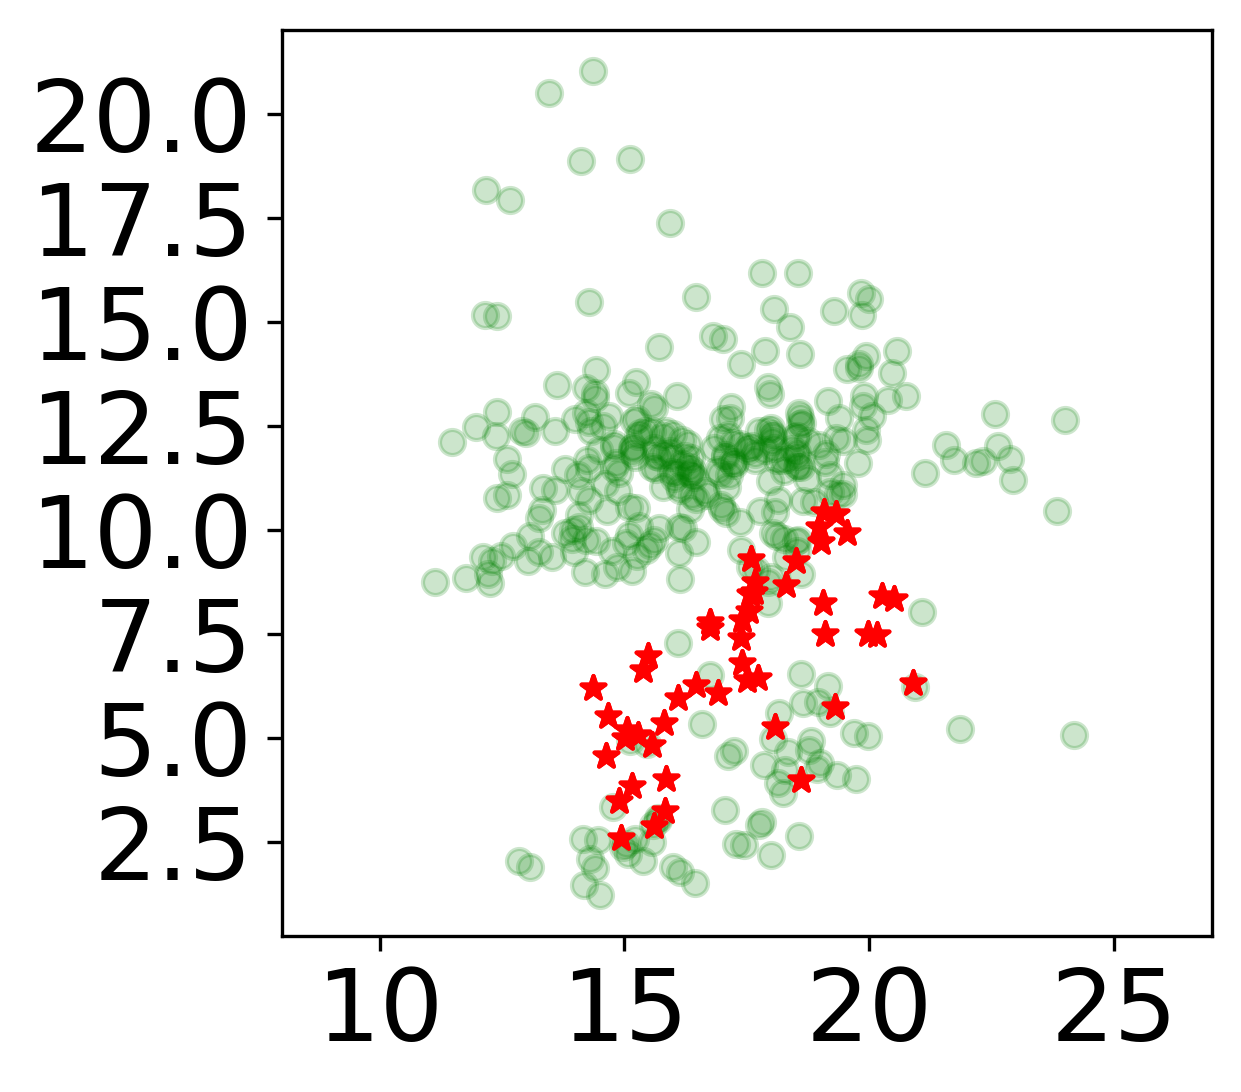

In [23]:
plt.figure(figsize=(4,4), dpi=300)
plt.scatter(new_data_csv['Diene_Distort_p'].to_numpy(), new_data_csv['Ene_Distort_p'].to_numpy(), alpha=0.2, c='green')
plt.scatter(BO_data_csv['Diene_Distort_p'].to_numpy(), BO_data_csv['Ene_Distort_p'].to_numpy(), alpha=1, c='red', marker='*')
plt.xticks(fontsize=24)
plt.yticks(fontsize=24)

# plt.scatter(new_data_csv['Diene_Distort_p'].to_numpy(), new_data_csv['Interaction_p'].to_numpy(), alpha=0.2, c='green')
# plt.scatter(BO_data_csv['Diene_Distort_p'].to_numpy(), BO_data_csv['Interaction_p'].to_numpy(), alpha=1, c='red', marker='*')

# plt.scatter(new_data_csv['Ene_Distort_p'].to_numpy(), new_data_csv['Interaction_p'].to_numpy(), alpha=0.2, c='green')
# plt.scatter(BO_data_csv['Ene_Distort_p'].to_numpy(), BO_data_csv['Interaction_p'].to_numpy(), alpha=1, c='red', marker='*')
# plt.xlabel("Diene Distortion")
# plt.ylabel("Ene Distortion")
plt.xlim(8, 27)
plt.savefig("Data/Predict_DI/BO_LowThan_22.png", dpi=300, bbox_inches = 'tight' )

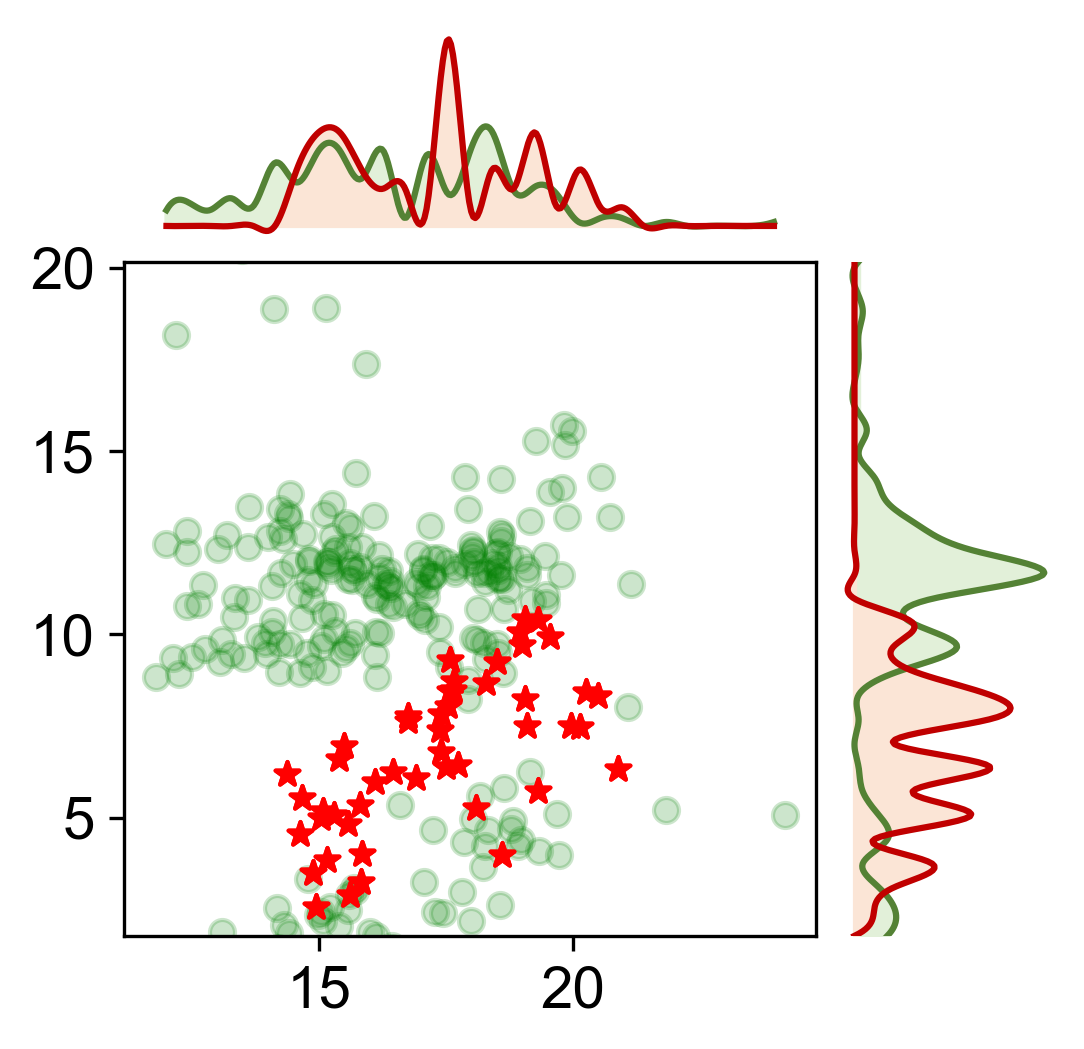

In [47]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import make_interp_spline

# new_data_csv = pd.read_csv(f"../Data/Predict_DI/deltaGa_LowThan_{deltaGa_limit}_stable.csv")
# BO_data_csv = pd.read_csv(f"Data/Predict_DI/BO_LowThan_{deltaGa_limit}_new.csv")

color_bars = (226/255, 240/255, 217/255)
color_line = (84/255, 130/255, 53/255)

color_bars2 = (251/255, 229/255, 214/255)
color_line2 = (192/255, 0/255, 0/255)

x_1 = new_data_csv['Diene_Distort_p'].to_numpy()
x_2 = BO_data_csv['Diene_Distort_p'].to_numpy()
y_1 = new_data_csv['Ene_Distort_p'].to_numpy()
y_2 = BO_data_csv['Ene_Distort_p'].to_numpy()
# y_1 = new_data_csv['Interaction_p'].to_numpy()
# y_2 = BO_data_csv['Interaction_p'].to_numpy()
# x_1 = new_data_csv['Ene_Distort_p'].to_numpy()
# x_2 = BO_data_csv['Ene_Distort_p'].to_numpy()

x_bins = np.linspace(min(x_1), max(x_1), 30)
y_bins = np.linspace(min(y_1), max(y_1), 30)

fig = plt.figure(figsize=(4, 4), facecolor='white', dpi=300)
plt.rcParams['font.sans-serif']='Arial'
ax_main = plt.subplot2grid((4, 4), (1, 0), rowspan=3, colspan=3)
ax_x_hist = plt.subplot2grid((4, 4), (0, 0), colspan=3, sharex=ax_main)
ax_y_hist = plt.subplot2grid((4, 4), (1, 3), rowspan=3, sharey=ax_main)
ax_main.tick_params(axis='both', which='major', labelsize=14)
ax_main.scatter(x_1, y_1, alpha=0.2, c='green')
ax_main.scatter(x_2, y_2, alpha=1, c='red', marker='*')

# ax_main.axis('off')
# fig.colorbar(pc, ax=ax_main)

# ax_x_hist.hist(x_1, bins=x_bins, color=color_bars, alpha=1)
x_hist, x_bin_edges = np.histogram(x_1, bins=x_bins)
x_hist = x_hist / len(x_1)
x_bin_centers = 0.5 * (x_bin_edges[:-1] + x_bin_edges[1:])
spl_x = make_interp_spline(x_bin_centers, x_hist, k=3)
x_smooth = np.linspace(x_bin_centers.min(), x_bin_centers.max(), 300)
y_smooth = spl_x(x_smooth)
ax_x_hist.plot(x_smooth, y_smooth, color=color_line)
ax_x_hist.fill_between(x_smooth, y_smooth, 0, where=(y_smooth > 0), interpolate=True, color=color_bars, alpha=1)
ax_x_hist.axis('off')

# ax_y_hist.hist(y_1, bins=y_bins, orientation='horizontal', color=color_bars, alpha=1)
y_hist, y_bin_edges = np.histogram(y_1, bins=y_bins)
y_hist = y_hist / len(x_1)
y_bin_centers = 0.5 * (y_bin_edges[:-1] + y_bin_edges[1:])
spl_y = make_interp_spline(y_bin_centers, y_hist, k=3)
y_smooth = np.linspace(y_bin_centers.min(), y_bin_centers.max(), 300)
x_smooth_y = spl_y(y_smooth)
ax_y_hist.plot(x_smooth_y, y_smooth, color=color_line)
ax_y_hist.fill_between(x_smooth_y, y_smooth, 0, where=(y_smooth > 0), interpolate=True, color=color_bars, alpha=1)
ax_y_hist.axis('off')

# ax_x_hist.hist(x_2, bins=x_bins, color=color_bars2, alpha=1)
x_hist, x_bin_edges = np.histogram(x_2, bins=x_bins)
x_hist = x_hist / len(x_2)
x_bin_centers = 0.5 * (x_bin_edges[:-1] + x_bin_edges[1:])
spl_x = make_interp_spline(x_bin_centers, x_hist, k=3)
x_smooth = np.linspace(x_bin_centers.min(), x_bin_centers.max(), 300)
y_smooth = spl_x(x_smooth)
ax_x_hist.plot(x_smooth, y_smooth, color=color_line2)
ax_x_hist.fill_between(x_smooth, y_smooth, 0, where=(y_smooth > 0), interpolate=True, color=color_bars2, alpha=1)
ax_x_hist.axis('off')

# ax_y_hist.hist(y_2, bins=y_bins, orientation='horizontal', color=color_bars2, alpha=1)
y_hist, y_bin_edges = np.histogram(y_2, bins=y_bins)
y_hist = y_hist / len(x_2)
y_bin_centers = 0.5 * (y_bin_edges[:-1] + y_bin_edges[1:])
spl_y = make_interp_spline(y_bin_centers, y_hist, k=3)
y_smooth = np.linspace(y_bin_centers.min(), y_bin_centers.max(), 300)
x_smooth_y = spl_y(y_smooth)
ax_y_hist.plot(x_smooth_y, y_smooth, color=color_line2)
ax_y_hist.fill_between(x_smooth_y, y_smooth, 0, where=(y_smooth > 0), interpolate=True, color=color_bars2, alpha=1)
ax_y_hist.set_ylim(y_bin_centers.min(), y_bin_centers.max())
ax_y_hist.axis('off')
plt.subplots_adjust(hspace=0.1, wspace=0.1)
plt.savefig('2d_hist_norm.png', dpi=300, bbox_inches='tight')
plt.show()


(0.0, 0.18702952478262228)

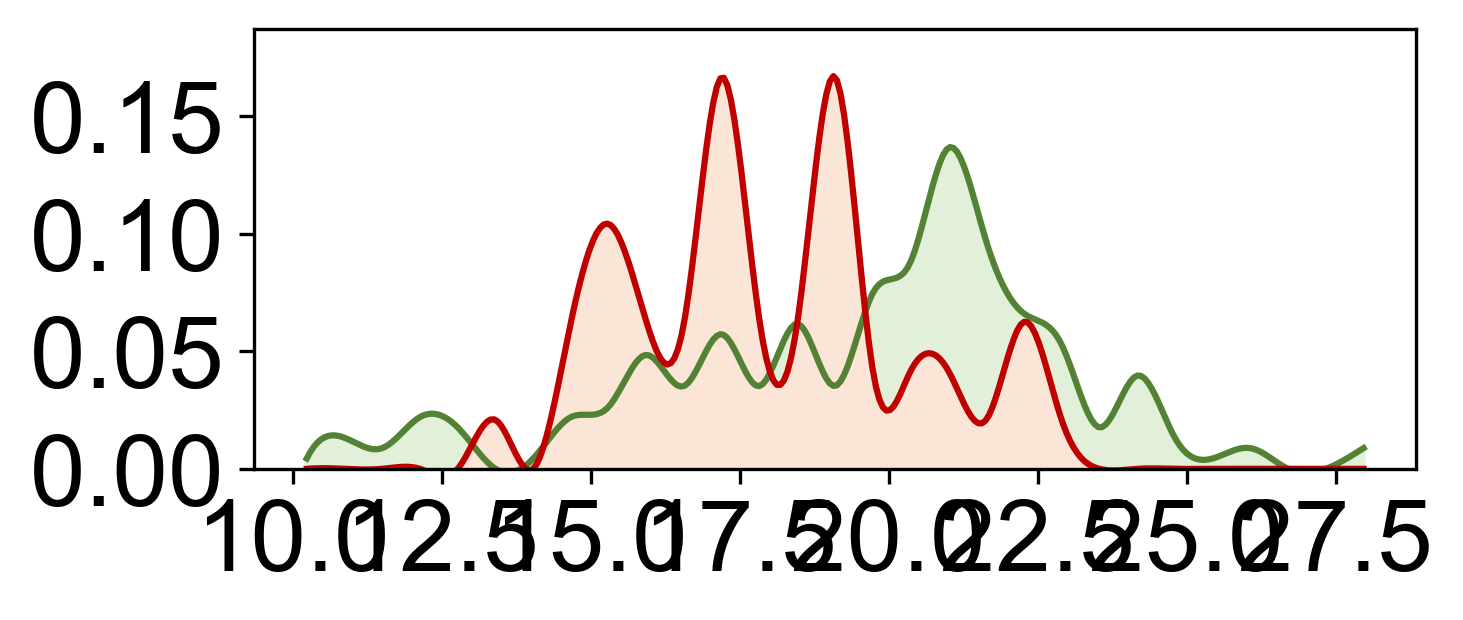

In [52]:
# Select The Part of Distribution
x_1 = new_data_csv['Interaction_p'].to_numpy() # Ene_Distort_p or Interaction_p
x_2 = BO_data_csv['Interaction_p'].to_numpy()
x_bins = np.linspace(min(x_1), max(x_1), 30)
plt.figure(figsize=(5,3),dpi=300)
ax_main = plt.subplot2grid((3,2), (1, 0), rowspan=3, colspan=3)
x_hist, x_bin_edges = np.histogram(x_1, bins=x_bins)
x_hist = x_hist / len(x_1)
x_bin_centers = 0.5 * (x_bin_edges[:-1] + x_bin_edges[1:])
spl_x = make_interp_spline(x_bin_centers, x_hist, k=3)
x_smooth = np.linspace(x_bin_centers.min(), x_bin_centers.max(), 300)
y_smooth = spl_x(x_smooth)
ax_main.plot(x_smooth, y_smooth, color=color_line)
ax_main.fill_between(x_smooth, y_smooth, 0, where=(y_smooth > 0), interpolate=True, color=color_bars, alpha=1)

x_hist, x_bin_edges = np.histogram(x_2, bins=x_bins)
x_hist = x_hist / len(x_2)
x_bin_centers = 0.5 * (x_bin_edges[:-1] + x_bin_edges[1:])
spl_x = make_interp_spline(x_bin_centers, x_hist, k=3)
x_smooth = np.linspace(x_bin_centers.min(), x_bin_centers.max(), 300)
y_smooth = spl_x(x_smooth)
ax_main.plot(x_smooth, y_smooth, color=color_line2)
ax_main.fill_between(x_smooth, y_smooth, 0, where=(y_smooth > 0), interpolate=True, color=color_bars2, alpha=1)
plt.xticks(fontsize=24)
plt.yticks(fontsize=24)
plt.ylim(0, y_smooth.max() + 0.02)
# plt.xlim(x_bin_centers.min() - 2, x_bin_centers.max() + 2)

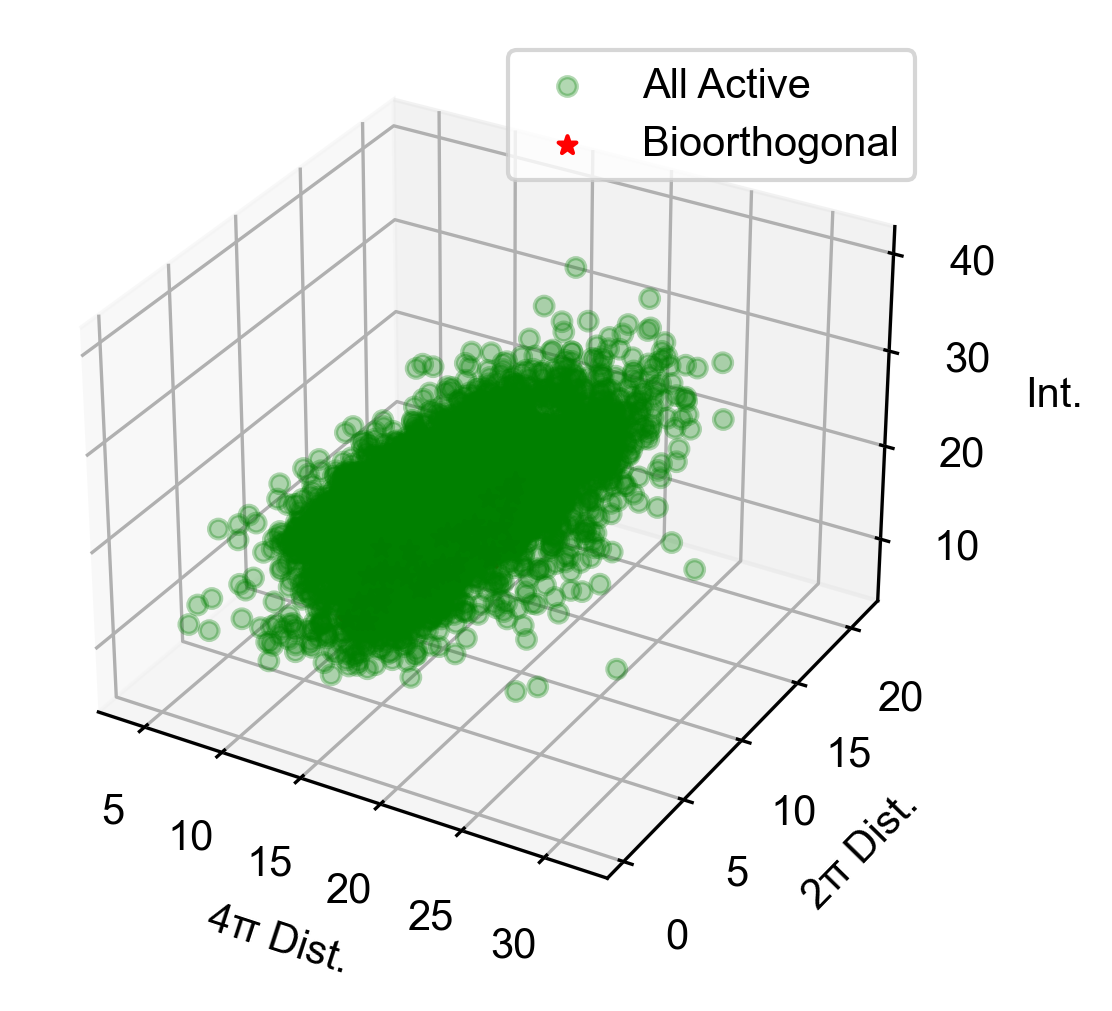

In [31]:
# Draw 3D Maps
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

np.random.seed(0)  
num_points = 100

x1 = new_data_csv['Diene_Distort_p'].to_numpy()
y1 = new_data_csv['Ene_Distort_p'].to_numpy()
z1 = new_data_csv['Interaction_p'].to_numpy()

x2 = BO_data_csv['Diene_Distort_p'].to_numpy()
y2 = BO_data_csv['Ene_Distort_p'].to_numpy()
z2 = BO_data_csv['Interaction_p'].to_numpy()

fig = plt.figure(figsize=(4,4), dpi=300)
ax = fig.add_subplot(111, projection='3d')

ax.scatter(x1, y1, z1, c='g', marker='o', label='All Active', alpha=0.3)

ax.scatter(x2, y2, z2, c='r', marker='*', label='Bioorthogonal')

ax.set_xlabel('4π Dist.')
ax.set_ylabel('2π Dist.')
ax.set_zlabel('Int.')
ax.legend()

plt.show()


## 4.3 Select The Potential Bioorthogonal Reactions

In [ ]:
Diene_Distort_p 14.35056813 20.90352287
Ene_Distort_p 2.581523905 10.42969865
Interaction_p 13.55325353 22.69300793

In [24]:
banned_bo_diene = [17301, 17558, 13755, 13782]
banned_bo_ene = [17935, 13787, 16502, 13758, 17291, 17301, 17558, 13755]
banned_bo_diene = [17935, 13787, 16502, 13758, 17291, 13569]
banned_bo_ene = [17935, 13787, 16502, 13758, 17291, 13569]
# banned_bo_ene = []

# already_bo_diene = [3998, 5944, 11875, 12881, 13304, 13432, 17928, 18043, 257, 11953, 11954]
# already_bo_ene = [17541, 17543, 12040, 17545, 17676, 17559, 17048, 14107, 18100, 18101, 13755, 13756, 17090, 13762, 13763, 18119, 18121, 13769, 14538, 17617, 13777, 13781, 17749, 17750, 13787, 15836, 18025, 17772, 11948, 8319, 10960, 6308]

# target_rows = pd.read_csv(f"Data/Predict_DI/deltaGa_LowThan_{deltaGa_limit}_stable.csv")
target_rows = pd.read_csv(f"Data/Predict_DI/4_DropActive.csv")
print(len(target_rows))
# target_rows = pd.read_csv("Data/Predict_DI/BO_LowThan_20.csv")
# target_rows = target_rows.loc[~(np.isin(target_rows['Diene_Index'], banned_bo_diene) | np.isin(target_rows['Ene_Index'], banned_bo_ene))]
up_bar = 1.1
down_bar = 0.9
# avaliable_id = (target_rows['Diene_Distort_p'] > 14.4 * down_bar) & (target_rows['Ene_Distort_p'] < 20.9 * up_bar) & (target_rows['Ene_Distort_p'] > 2.6 * down_bar) & (target_rows['Ene_Distort_p'] < 10.4 * up_bar) & (target_rows['Interaction_p'] > 13.5 * down_bar) & (target_rows['Interaction_p'] < 22.7 * up_bar)
avaliable_id = (target_rows['Diene_Distort_p'] > 14 ) & (target_rows['Ene_Distort_p'] < 11.0)
avaliable_rows = target_rows.loc[avaliable_id]
dropped_rows = target_rows.loc[~avaliable_id]
print(len(avaliable_rows), len(dropped_rows))

324
118 206


In [25]:
avaliable_rows.to_csv(f"Data/Predict_DI/5_DI.csv", index=False)
dropped_rows.to_csv(f"Data/Predict_DI/5_DI_Dropped.csv", index=False)

In [26]:
unin_stock_idxs = [18025, 17558, 17773, 18115, 12063, 13755, 13779, 13793, 13979, 14016, 14046, 15683, 15702,
12571, 12574, 12830, 13148, 13153, 13471, 13517, 13526, 13772, 13782, 14232, 15695, 15757, 16220, 16222, 16890,
17301, 17512, 17859, 17906, 18364] + [17935, 13787, 16502, 13758, 17291, 13569] + [17702, 16891, 17237, 18311, 14743, 14545, 14572, 14666] 
unin_stock_idxs.sort()
avaliable_rows = avaliable_rows.loc[~np.isin(avaliable_rows['Diene_Index'], unin_stock_idxs)]
avaliable_rows = avaliable_rows.loc[~np.isin(avaliable_rows['Ene_Index'], unin_stock_idxs)]
avaliable_rows.to_csv(f"Data/Predict_DI/6_Potential_BO.csv", index=False)
len(avaliable_rows), len(set(avaliable_rows["Diene_Index"])), len(set(avaliable_rows["Ene_Index"]))
dienes = np.unique(avaliable_rows['Diene'].to_numpy())
enes = np.unique(avaliable_rows['Ene'].to_numpy())
diene_mols = [Chem.MolFromSmiles(d) for d in dienes]
ene_mols = [Chem.MolFromSmiles(e) for e in enes]
len(diene_mols), len(ene_mols), len(avaliable_rows)

(32, 10, 41)

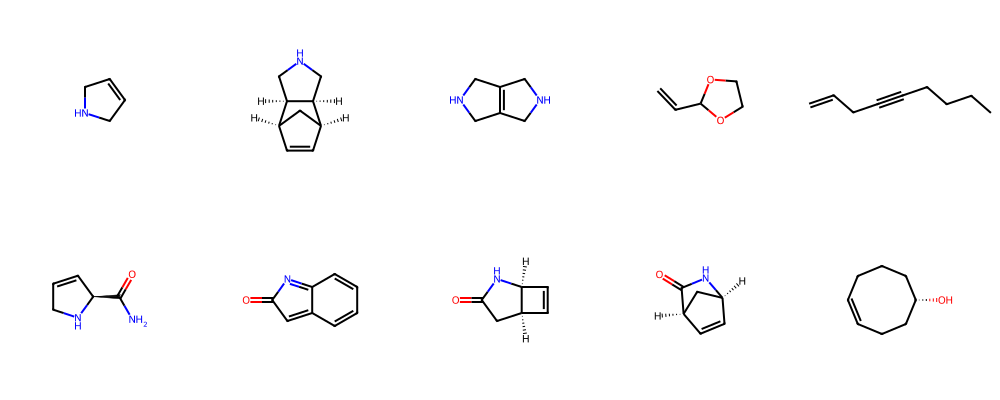

In [30]:
Chem.Draw.MolsToGridImage(ene_mols, molsPerRow=5, subImgSize=(200, 200), useSVG=1)

In [54]:
unin_stock_idxs = [18025, 17558, 17773, 18115, 12063, 13755, 13779, 13793, 13979, 14016, 14046, 15683, 15702,
12571, 12574, 12830, 13148, 13153, 13471, 13517, 13526, 13772, 13782, 14232, 15695, 15757, 16220, 16222, 16890,
17301, 17512, 17859, 17906, 18364]
unin_stock_idxs.sort()
unin_stock_idxs
final_csv = pd.read_csv(r"G:\work\Secondary_Selection\6_Potential_BO\Result_.csv")
final_csv = final_csv.dropna()
# final_csv = final_csv.loc[~np.isin(final_csv['Diene_Index'], unin_stock_idxs)]
# final_csv = final_csv.loc[~np.isin(final_csv['Ene_Index'], unin_stock_idxs)]
final_csv = final_csv.loc[final_csv.groupby(['Diene_Index', 'Ene_Index'])['deltaGa(Solvent)'].idxmin()]
final_csv.to_csv(r"G:\work\Secondary_Selection\6_Potential_BO\Result_one.csv", index=False)

### Pred Vs DFT

3.2606757728205125


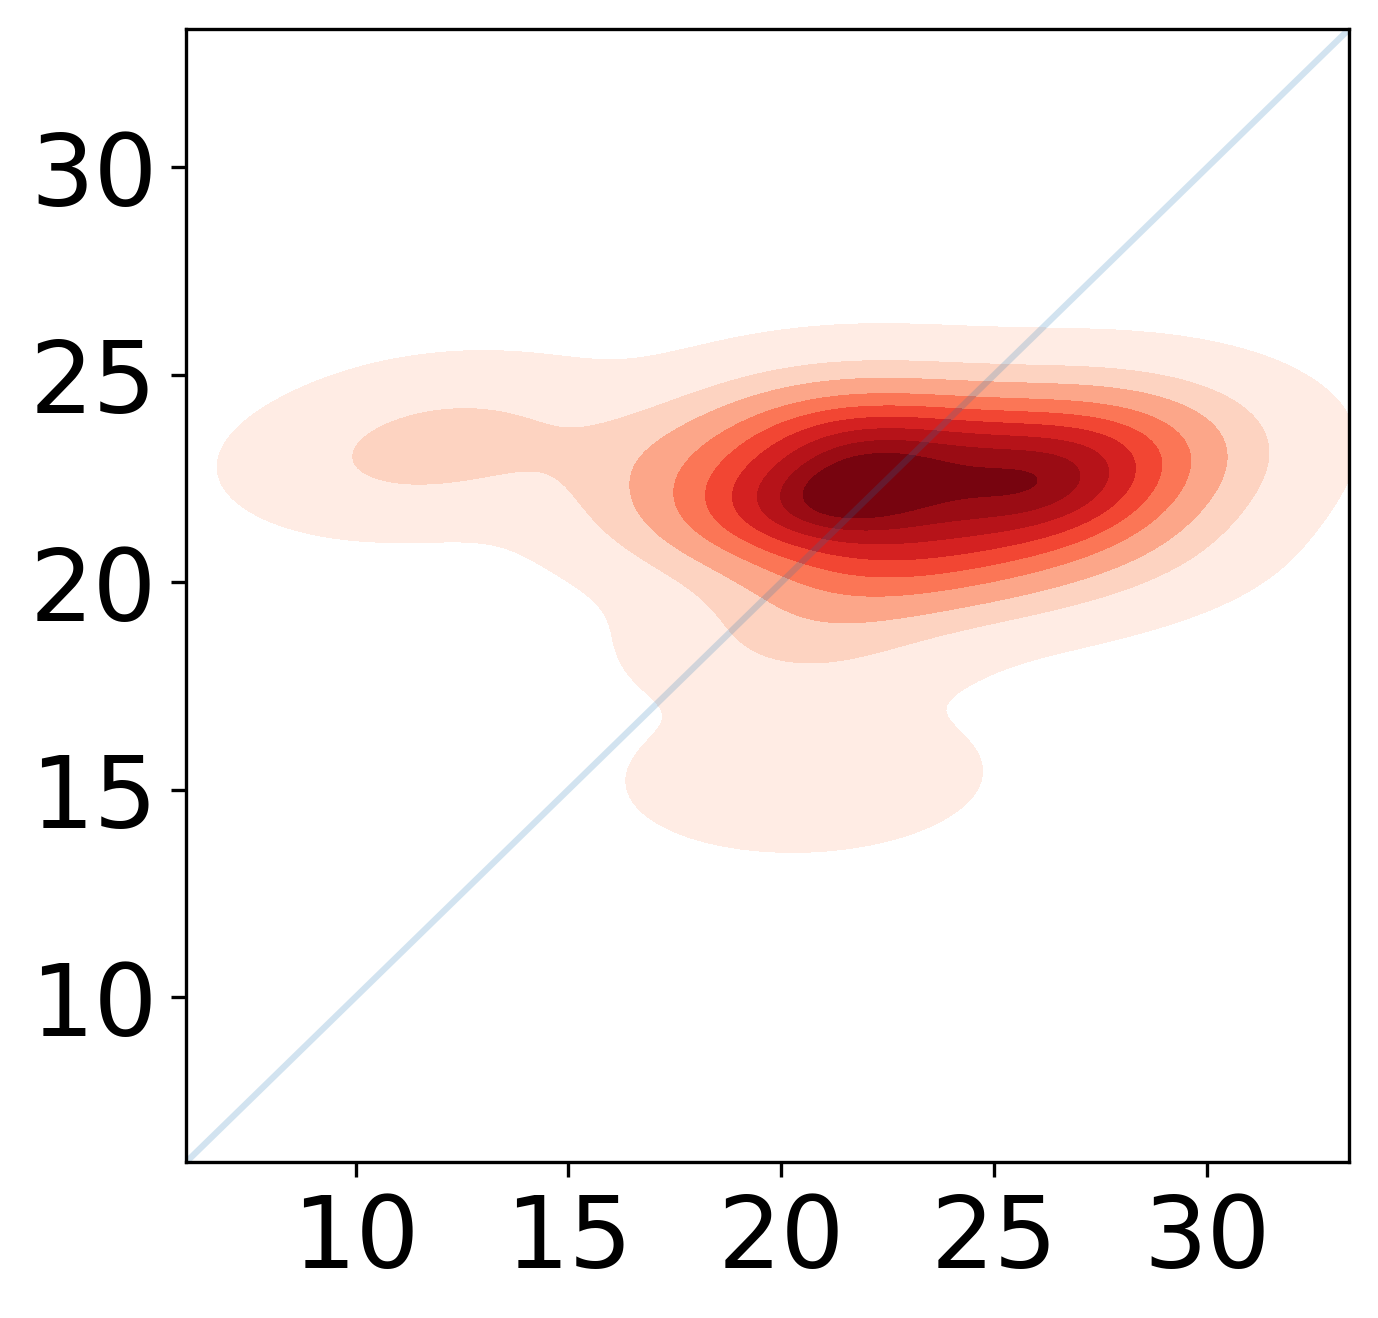

In [12]:
df = pd.read_csv(r"G:\work\Secondary_Selection\6_Potential_BO\Result_one.csv")
# x = df['deltaG']
# y = df['deltaG_p']
# x = df["Diene_Distort"]
# y = df['Diene_Distort_p']
# x = df["Ene_Distort"]
# y = df['Ene_Distort_p']
# x = df["Interaction"]
# y = df['Interaction_p']
# x = df["deltaGa(Solvent)"]
# y = df['deltaGa(Solvent)_p']
print(mean_absolute_error(x,y))
model_train.plot_scatter_with_metrics(x,y)

## 4.4 Analysis Potential Bioorthogonal Reaction

In [8]:
from pyecharts.charts import Sankey
from pyecharts import options as opts

In [20]:
Chem.MolFromSmiles("C=CC=C").GetSubstructMatches(Chem.MolFromSmarts("a=a"))

()

In [21]:
diene_smarts = ["A=AA=A", 'aaaa', 'C(=O)N']
ene_smarts = ["[CH2]=*", "[r4,r5]=[r4,r5]", "[r8]=[r8]"]

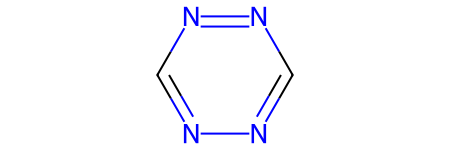

In [22]:
diene

In [24]:
diene_matches

['A=AA=A']

In [23]:
nodes = [{"name":each} for each in diene_smarts + ene_smarts]
node_encluding = {each:[] for each in diene_smarts + ene_smarts}
link_dict = {}
final_csv = pd.read_csv(r"Data/Predict_DI/6_Potential_BO.csv")
for row_id, row in final_csv.iterrows():
    diene = Chem.MolFromSmiles(row['Diene'])
    ene = Chem.MolFromSmiles(row['Ene'])
    diene_matches = [smarts for smarts in diene_smarts if diene.HasSubstructMatch(Chem.MolFromSmarts(smarts))]
    ene_matches = [smarts for smarts in ene_smarts if ene.HasSubstructMatch(Chem.MolFromSmarts(smarts))]
    assert len(diene_matches) == len(ene_matches) == 1
    node_encluding[diene_matches[0]].append(diene)
    node_encluding[ene_matches[0]].append(ene)
    target_part = diene_matches[0] + "^" + ene_matches[0]
    if target_part not in link_dict.keys():
        link_dict[target_part] = 1
    else:
        link_dict[target_part] += 1
links = [{"source": each.split("^")[0], "target": each.split("^")[1], "value": link_dict[each]} for each in link_dict.keys()]
sankey = Sankey(init_opts=opts.InitOpts(width="200px", height="600px", is_horizontal_center=True))
sankey.add(
    "",    
    nodes,                 
    links,                     
    linestyle_opt=opts.LineStyleOpts(opacity=0.3, curve=0.5, color='source'),  # 设置曲线弯曲度
    label_opts=opts.LabelOpts(is_show=False),  # 隐藏节点名称
    node_gap=5
)
sankey.render("sankey_diagram.html")

'd:\\OneDrive_all\\OneDrive\\Work\\work_part\\9.CycloAddGenerator\\sankey_diagram.html'

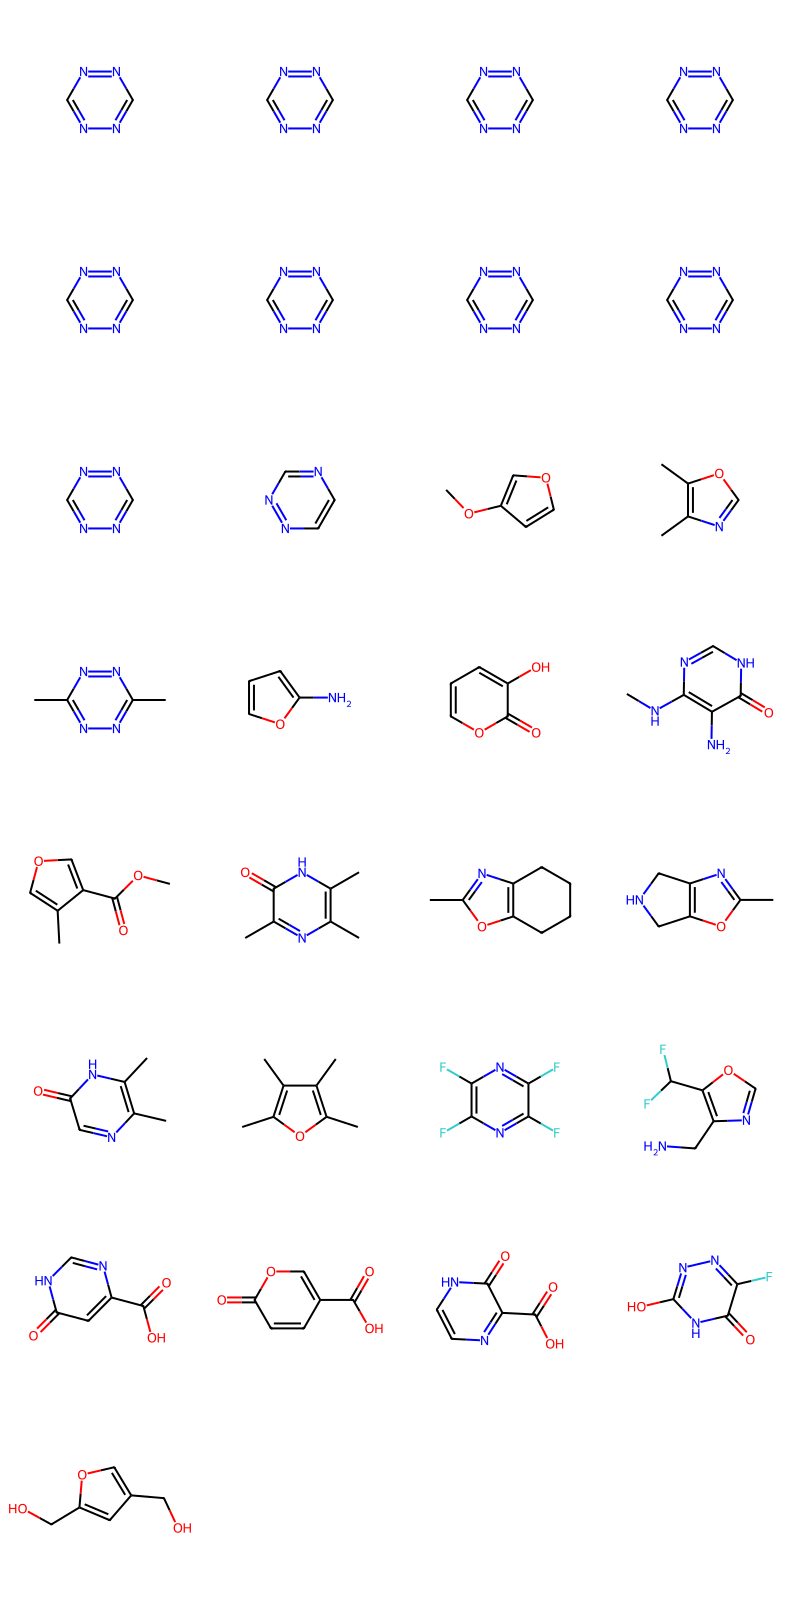

In [29]:
id = 1
Chem.Draw.MolsToGridImage(node_encluding[nodes[id]['name']], molsPerRow=4, subImgSize=(200, 200))

In [66]:

# import pandas as pd


all_smiles = list(set(final_csv['Diene'].tolist() + final_csv['Ene'].tolist()))
nodes = [{"name": each} for each in all_smiles]
links = []
for diene, ene in zip(final_csv['Diene'].to_numpy(), final_csv['Ene'].to_numpy()):
    links.append({"source": diene, "target": ene, "value": 10})

sankey = Sankey(init_opts=opts.InitOpts(width="200px", height="400px", is_horizontal_center=True))

sankey.add(
    "",    
    nodes,                 
    links,                     
    linestyle_opt=opts.LineStyleOpts(opacity=0.3, curve=0.5, color='source'),  # 设置曲线弯曲度
    label_opts=opts.LabelOpts(is_show=False)  # 隐藏节点名称, 
)
sankey.render("sankey_diagram.html")

TypeError: add() got an unexpected keyword argument 'node_label_opts'